# **스테이지 3. 모델링 기초**

In [ ]:
# drive에 연결합니다.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 현재 데이터가 있는 공간으로 작업 경로를 변경해줍니다.
%cd "/content/drive/MyDrive/AI/Data Set/신용카드_사용자 연체 예측"

Mounted at /content/drive
/content/drive/MyDrive/ML_Data/Dacon/데이크루6기/신용카드/open


In [ ]:
# pandas 패키지를 pd라는 별칭으로 불러옵니다.
import pandas as pd

# train 데이터를 불러옵니다.
train = pd.read_csv('train.csv')
# test 데이터를 불러옵니다.
test = pd.read_csv('test.csv')
# submission 데이터를 불러옵니다.
submission = pd.read_csv('sample_submission.csv')

<img src="https://www.nvidia.com/content/dam/en-zz/Solutions/glossary/data-science/machine-learning/img-1.png">

### **1. Feature & Target**

첫 번째는 Feature와 Target입니다.<br>
feature는 예측을 위해 모델이 학습하는 변수들을 말합니다! 독립변수 X라고도 불립니다.<br>
target은 모델이 예측하고자 하는 대상입니다!<br>
모델은 feature를 통해 target과의 관계, 패턴 등을 학습하고 결과를 만들어냅니다. 종속변수 Y라고도 불립니다.<br>

train 데이터셋에서 Target은 `credit` 변수, Feature는 나머지 변수가 됩니다

### **2. Problem Type (Regression vs Classification)**

두 번째는 예측 문제 유형의 정의입니다!<br>
예측 문제는 주로 회귀(Regression)과 분류(Classification) 문제로 나눌 수 있습니다.<br>
둘 중 어떤 문제로 정의할지는 Target 데이터의 특성에 따라 결정됩니다.


#### **회귀(Regression)**
* Target 데이터가 연속적인 값을 가질 때 이를 예측하기 위해 사용됩니다.<br>
* 대표적으로 주택 가격 예측 등의 문제가 있습니다.

#### **분류(Classification)**
* Target 데이터가 여러 개의 이산적인 값을 가질 때 이를 예측하기 위해 사용됩니다.
* 대표적으로 스팸 메일 분류, 이미지 분류 등의 문제가 있습니다.

In [ ]:
# credit 변수를 살펴봅니다
train["credit"].value_counts()

2.0    16968
1.0     6267
0.0     3222
Name: credit, dtype: int64

## **Step 1. 모델링**

이제 가장 널리 사용되는 분류 모델을 배워보겠습니다.<br>
이번에 같이 사용해볼 모델은 의사결정나무 분류기(Decision Tree Classifier)입니다!<br>

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_iris_dtc_002.png"><br>

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier(random_state=42)

In [ ]:
# sklearn 패키지의 tree 모듈에서 DecisionTreeClassifier 객체를 불러옵니다
from sklearn.tree import DecisionTreeClassifier
# model이라는 변수에 DecisionTreeClassifier 객체를 할당합니다
model = DecisionTreeClassifier(random_state=42)

## **Step 2. 레이블 인코딩**

레이블 인코딩이란?<br>

레이블 인코딩(Label Encoding)은 카테고리형 데이터를 수치형 데이터로 변환하는 방법 중 하나입니다.<br>
머신 러닝 알고리즘에 입력 데이터로 사용하기 위해, 문자열 형태의 카테고리를 숫자로 변환하는 프로세스를 의미합니다.

예를 들어, 아래의 대륙들은 각각 1부터 6이라는 고유의 숫자로 변환된 것을 볼 수 있습니다!

<img src="https://machinelearningknowledge.ai/wp-content/uploads/2021/09/LE.pic1_-300x275.png">

In [ ]:
# sklearn 패키지의 preprocessing 모듈에서 LabelEncoder 함수를 불러옵니다
from sklearn.preprocessing import LabelEncoder

# le라는 변수에 LabelEncoder 함수를 할당합니다
le = LabelEncoder()

In [ ]:
# LabelEncoder로 object 타입 변수들을 수치형 데이터로 변환해줍니다
cols = train.select_dtypes(include=['object']).columns

for col in cols:
    train[col] = le.fit_transform(train[col])
    test[col] = le.fit_transform(test[col])

In [ ]:
# 변환 결과를 확인합니다
train.head()

,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit
0,0,0,0,0,0,202500.0,0,1,1,2,38.079452,12.901370,1,0,0,0,12,2.0,6.0,1.0
1,1,0,0,1,1,247500.0,0,4,0,1,31.178082,4.219178,1,0,0,1,8,3.0,5.0,1.0
2,2,1,1,1,0,450000.0,4,1,1,1,52.293151,12.147945,1,0,1,0,10,2.0,22.0,2.0
3,3,0,0,1,0,202500.0,0,4,1,1,41.336986,5.731507,1,0,1,0,15,2.0,37.0,0.0
4,4,0,1,1,0,157500.0,2,1,1,1,41.197260,5.767123,1,0,0,0,10,2.0,26.0,2.0


## **Step 3. 데이터 나누기**

In [ ]:
# train 데이터를 독립변수 X와 종속변수 y로 나눠줍니다
X = train.drop(columns="credit")
y = train["credit"]

train과 test는 각각 학습용과 테스트용 데이터입니다.<br>
모델 학습을 할 때, 우리는 train만 사용하게 됩니다!<br>

<img src="https://miro.medium.com/v2/resize:fit:1400/1*f2KznlrIdj1MeobprVGBtg.png">

보통 데이터셋은 **Train / Valid / Test**의 세 가지로 나눠서 진행하게 되고, 각각의 역할은 다음과 같습니다.
* Train: 모델을 훈련하는 데 사용됩니다. 이 데이터셋을 가지고 모델의 가중치를 업데이트하게 됩니다.
* Valid: 모델의 하이퍼파라미터 조정 및 성능 평가에 사용됩니다.
* Test: 최종 모델로부터 예측 결과를 만들어내는 데 사용됩니다.

일반적으로 Valid 데이터셋은 전체 데이터의 10 ~ 20%의 비율을 차지합니다!<br>
Valid 데이터셋은 모델의 일반화 성능을 높이기 위해 사용되고 최적의 하이퍼파라미터를<br>
찾는 데에 사용되는 데이터셋입니다.

In [ ]:
# sklearn 패키지의 train_test_split 함수를 불러옵니다
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

## **Step 4. 모델 학습 및 평가**



In [ ]:
# model의 학습을 진행합니다
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_valid)
acc = accuracy_score(y_valid, y_pred)
print(f"Accuracy: {round(acc, 4)}")

Accuracy: 0.5865


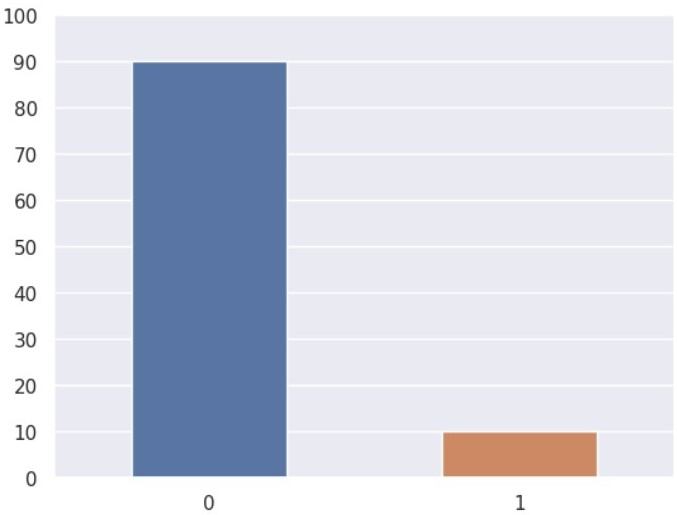

<img src="https://miro.medium.com/v2/resize:fit:1400/1*fxiTNIgOyvAombPJx5KGeA.png" width="700">

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_valid)
cm = confusion_matrix(y_valid, y_pred, labels=[0, 1, 2])
print(cm)

[[ 164  156  330]
 [ 174  521  567]
 [ 379  582 2419]]


## **Step 5. 예측하기 및 파일 제출**

In [ ]:
pred = model.predict_proba(test)

submission.iloc[:,1:] = pred
submission

,index,0,1,2
0,26457,0,0,1
1,26458,0,0,1
2,26459,1,0,0
3,26460,0,0,1
4,26461,0,1,0
...,...,...,...,...
9995,36452,0,0,1
9996,36453,1,0,0
9997,36454,0,1,0
9998,36455,0,1,0


In [ ]:
submission.to_csv("submission1.csv", index=False)